In [1]:
# Run this cell to set up packages for lecture.
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display, IFrame, YouTubeVideo

path = 'lectures/lec03'
if not Path("data").exists():
    !wget -q -O /content/course.zip https://github.com/dsc-courses/cosmos-ml-cluster-2026/archive/refs/heads/main.zip
    !unzip -q -o /content/course.zip "cosmos-ml-cluster-2026-main/{path}/data/*" -d /content/course-assets
    !cp -R /content/course-assets/cosmos-ml-cluster-2026-main/{path}/data .

np.set_printoptions(threshold=20, precision=2, suppress=True)
pd.set_option("display.max_rows", 7)
pd.set_option("display.max_columns", 8)
pd.set_option("display.precision", 2)

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 5)

def show_grouping_animation():
    src = "https://docs.google.com/presentation/d/1IBMwlqBtnD-Ml1Zhmqs6pnYV6jcYayr3VGFqN9Dg3xk/embed?start=false&loop=false&delayms=60000&rm=minimal"
    width = 960
    height = 509
    display(IFrame(src, width, height))


# Lecture 3 - Querying and Grouping

## COSMOS ML Cluster 2026

### Agenda

- Querying.
- Querying with multiple conditions.
- Grouping.
- After class: challenge problems.

### You belong here! 🤝

- We're moving _very_ quickly in this class.
- This may be the first time you're ever writing Python code, and you may question whether or not you belong in this class, or if data science is for you.
- We promise, no matter what your prior experience is, **the answer is yes, you belong!**
    - Watch: [🎥 Developing a Growth Mindset with Carol Dweck](https://www.youtube.com/watch?v=hiiEeMN7vbQ).
- Please ask us for help - we want you to succeed!

### The data: US states  🗽

We'll continue working with the same data from last time.

In [2]:
states = pd.read_csv('data/states.csv')
states = states.assign(Density=states.get('Population') / states.get('Land Area'))
states = states.set_index('State')
states

,Region,Capital City,Population,Land Area,Party,Density
State,,,,,,
Alabama,South,Montgomery,5024279,50645,Republican,99.21
Alaska,West,Juneau,733391,570641,Republican,1.29
Arizona,West,Phoenix,7151502,113594,Republican,62.96
...,...,...,...,...,...,...
West Virginia,South,Charleston,1793716,24038,Republican,74.62
Wisconsin,Midwest,Madison,5893718,54158,Republican,108.82
Wyoming,West,Cheyenne,576851,97093,Republican,5.94


## Example 1: Which states are in the West?

**Key concept**: Querying.

### The problem

We want to create a DataFrame consisting of only the states whose `'Region'` is `'West'`. How do we do that?

### The solution

In [3]:
# This DataFrame only contains rows where the 'Region' is 'West'!
only_west = states[states.get('Region') == 'West']
only_west

,Region,Capital City,Population,Land Area,Party,Density
State,,,,,,
Alaska,West,Juneau,733391,570641,Republican,1.29
Arizona,West,Phoenix,7151502,113594,Republican,62.96
California,West,Sacramento,39538223,155779,Democratic,253.81
...,...,...,...,...,...,...
Utah,West,Salt Lake City,3271616,82170,Republican,39.82
Washington,West,Olympia,7705281,66456,Democratic,115.95
Wyoming,West,Cheyenne,576851,97093,Republican,5.94


🤯 What just happened?

### Aside: Booleans

- When we compare two values, the result is either `True` or `False`.
    - Notice, these words are **not** in quotes.
- `bool` is a data type in Python, just like `int`, `float`, and `str`. 
    - It stands for "Boolean", named after George Boole, an early mathematician.
- There are only two possible Boolean values: `True` or `False`.
    - Yes or no.
    - On or off.
    - 1 or 0.

In [4]:
5 == 6

False

In [5]:
type(5 == 6)

bool

In [6]:
9 + 10 < 21

True

### Comparison operators

There are several types of comparisons we can make.

|symbol|meaning|
|--------|--------|
|`==` |equal to |
|`!=` |not equal to |
|`<`|less than|
|`<=`|less than or equal to|
|`>`|greater than|
|`>=`|greater than or equal to|

When comparing an entire Series to a single value, the result is a Series of `bool`s (via broadcasting).

In [7]:
states

,Region,Capital City,Population,Land Area,Party,Density
State,,,,,,
Alabama,South,Montgomery,5024279,50645,Republican,99.21
Alaska,West,Juneau,733391,570641,Republican,1.29
Arizona,West,Phoenix,7151502,113594,Republican,62.96
...,...,...,...,...,...,...
West Virginia,South,Charleston,1793716,24038,Republican,74.62
Wisconsin,Midwest,Madison,5893718,54158,Republican,108.82
Wyoming,West,Cheyenne,576851,97093,Republican,5.94


In [8]:
states.get('Region') == 'West'

State
Alabama          False
Alaska            True
Arizona           True
                 ...  
West Virginia    False
Wisconsin        False
Wyoming           True
Name: Region, Length: 50, dtype: bool

### What is a query? 🤔

- A *query* is code that extracts rows from a DataFrame for which certain condition(s) are true.
- We use queries to *filter* DataFrames to contain only the rows that satisfy given conditions.

### How do we query a DataFrame?

To select only certain rows of `states`:

1. Make a sequence (list/array/Series) of `True`s (keep) and `False`s (toss), usually by making a comparison.
2. Then pass it into `states[sequence_goes_here]`.

In [9]:
states[states.get('Region') == 'West']

,Region,Capital City,Population,Land Area,Party,Density
State,,,,,,
Alaska,West,Juneau,733391,570641,Republican,1.29
Arizona,West,Phoenix,7151502,113594,Republican,62.96
California,West,Sacramento,39538223,155779,Democratic,253.81
...,...,...,...,...,...,...
Utah,West,Salt Lake City,3271616,82170,Republican,39.82
Washington,West,Olympia,7705281,66456,Democratic,115.95
Wyoming,West,Cheyenne,576851,97093,Republican,5.94


### What if the condition isn't satisfied?

In [10]:
states[states.get('Region') == 'Pacific Northwest']

,Region,Capital City,Population,Land Area,Party,Density
State,,,,,,


## Example 2: What proportion of US states are Republican?

**Key concept**: Shape of a DataFrame. 

##### Strategy
1. Query to extract a DataFrame of just the states where the `'Party'` is `'Republican'`.
2. Count the number of such states.
3. Divide by the total number of states.

In [11]:
only_rep = states[states.get('Party') == 'Republican']
only_rep

,Region,Capital City,Population,Land Area,Party,Density
State,,,,,,
Alabama,South,Montgomery,5024279,50645,Republican,99.21
Alaska,West,Juneau,733391,570641,Republican,1.29
Arizona,West,Phoenix,7151502,113594,Republican,62.96
...,...,...,...,...,...,...
West Virginia,South,Charleston,1793716,24038,Republican,74.62
Wisconsin,Midwest,Madison,5893718,54158,Republican,108.82
Wyoming,West,Cheyenne,576851,97093,Republican,5.94


### Shape of a DataFrame

- `.shape` returns the number of rows and columns in a given DataFrame.
    - `.shape` is not a method, so we **don't use parentheses**.
    - `.shape` is an *attribute*, as it describes the DataFrame.
- Access each with `[]`: 
    - `.shape[0]` for rows.
    - `.shape[1]` for columns.

In [12]:
only_rep.shape

(31, 6)

In [13]:
# Number of rows.
only_rep.shape[0]

31

In [14]:
# Number of columns.
only_rep.shape[1]

6

In [15]:
# What proportion of US states are Republican?
only_rep.shape[0] / states.shape[0]

0.62

## Example 3: Which Midwestern state has the most land area?

**Key concepts**: Working with the index. Combining multiple steps.

##### Strategy
1. Query to extract a DataFrame of just the states in the `'Midwest'`.
2. Sort by `'Land Area'` in descending order.
3. Extract the first element from the index.

In [16]:
midwest = states[states.get('Region') == 'Midwest']
midwest

,Region,Capital City,Population,Land Area,Party,Density
State,,,,,,
Illinois,Midwest,Springfield,12812508,55519,Democratic,230.78
Indiana,Midwest,Indianapolis,6785528,35826,Republican,189.40
Iowa,Midwest,Des Moines,3190369,55857,Republican,57.12
...,...,...,...,...,...,...
Ohio,Midwest,Columbus,11799448,40861,Republican,288.77
South Dakota,Midwest,Pierre,886667,75811,Republican,11.70
Wisconsin,Midwest,Madison,5893718,54158,Republican,108.82


In [17]:
midwest_sorted = midwest.sort_values(by='Land Area', ascending=False)
midwest_sorted

,Region,Capital City,Population,Land Area,Party,Density
State,,,,,,
Kansas,Midwest,Topeka,2937880,81759,Republican,35.93
Minnesota,Midwest,Saint Paul,5706494,79627,Democratic,71.67
Nebraska,Midwest,Lincoln,1961504,76824,Republican,25.53
...,...,...,...,...,...,...
Wisconsin,Midwest,Madison,5893718,54158,Republican,108.82
Ohio,Midwest,Columbus,11799448,40861,Republican,288.77
Indiana,Midwest,Indianapolis,6785528,35826,Republican,189.40


- The answer is Kansas, but how do we get it in code?

In [18]:
midwest_sorted.get('State').iloc[0]

AttributeError: 'NoneType' object has no attribute 'iloc'

### Working with the index

- We can't use `.get` because `.get` is only for columns, and there is no column called `'State'`. 
    - Instead, `'State'` is the index of the DataFrame. 
- To extract the index of a DataFrame, use `.index`.
    - Like `.shape`, this is an attribute of the DataFrame, not a method. Don't use parentheses.  
- Access particular elements in the index with `[]`.

In [19]:
midwest_sorted.index

Index(['Kansas', 'Minnesota', 'Nebraska', 'South Dakota', 'North Dakota',
       'Missouri', 'Michigan', 'Iowa', 'Illinois', 'Wisconsin', 'Ohio',
       'Indiana'],
      dtype='str', name='State')

In [20]:
midwest_sorted.index[0]

'Kansas'

### Combining multiple steps

- It is not necessary to define the intermediate variables `midwest` and `midwest_sorted`. We can do everything in one line of code.

- When solving a multi-step problem, develop your solution incrementally. Write one piece of code at a time and run it.

In [21]:
# Final solution, which you should build up one step at a time.
states[states.get('Region') == 'Midwest'].sort_values(by='Land Area', ascending=False).index[0]

'Kansas'

- If a line of code gets too long, enclose it in parentheses to split it over multiple lines.

In [22]:
# You can space your code out like this if needed.
(
    states[states.get('Region') == 'Midwest']
    .sort_values(by='Land Area', ascending=False)
    .index[0]
)

'Kansas'

### Concept Check

Which expression below evaluates to **the total population of the `'West'`**?

A. `states[states.get('Region') == 'West'].get('Population').sum()`

B. `states.get('Population').sum()[states.get('Region') == 'West']`

C. `states['West'].get('Population').sum()`
   
D. More than one of the above.

In [23]:
...

Ellipsis

## Example 4: What are the top three most-populated Republican states in the South?

**Key concepts**: Queries with multiple conditions. Selecting rows by position.

### Multiple conditions

- To write a query with multiple conditions, use `&` for "and" and `|` for "or".
    - `&`: All conditions must be true.
    - `|`: At least one condition must be true.
- **You must use `(`parentheses`)` around each condition!**
- 🚨 Don't use the Python keywords `and` and `or` here! They do not behave as you'd want.
    - This is a special rule for combining pandas Series of `True` and `False` values.

In [24]:
states[(states.get('Party') == 'Republican') & (states.get('Region') == 'South')]

,Region,Capital City,Population,Land Area,Party,Density
State,,,,,,
Alabama,South,Montgomery,5024279,50645,Republican,99.21
Arkansas,South,Little Rock,3011524,52035,Republican,57.87
Florida,South,Tallahassee,21538187,53625,Republican,401.64
...,...,...,...,...,...,...
Tennessee,South,Nashville,6910840,41235,Republican,167.60
Texas,South,Austin,29145505,261232,Republican,111.57
West Virginia,South,Charleston,1793716,24038,Republican,74.62


In [25]:
# You can also add line breaks within brackets.
states[(states.get('Party') == 'Republican') & 
       (states.get('Region') == 'South')]

,Region,Capital City,Population,Land Area,Party,Density
State,,,,,,
Alabama,South,Montgomery,5024279,50645,Republican,99.21
Arkansas,South,Little Rock,3011524,52035,Republican,57.87
Florida,South,Tallahassee,21538187,53625,Republican,401.64
...,...,...,...,...,...,...
Tennessee,South,Nashville,6910840,41235,Republican,167.60
Texas,South,Austin,29145505,261232,Republican,111.57
West Virginia,South,Charleston,1793716,24038,Republican,74.62


### The `&` and `|` operators work element-wise!

In [26]:
(states.get('Party') == 'Republican')

State
Alabama          True
Alaska           True
Arizona          True
                 ... 
West Virginia    True
Wisconsin        True
Wyoming          True
Name: Party, Length: 50, dtype: bool

In [27]:
(states.get('Region') == 'South')

State
Alabama           True
Alaska           False
Arizona          False
                 ...  
West Virginia     True
Wisconsin        False
Wyoming          False
Name: Region, Length: 50, dtype: bool

In [28]:
(states.get('Party') == 'Republican') & (states.get('Region') == 'South')

State
Alabama           True
Alaska           False
Arizona          False
                 ...  
West Virginia     True
Wisconsin        False
Wyoming          False
Length: 50, dtype: bool

### Original Question: What are the top three most-populated Republican states in the South?

In [29]:
(
    states[(states.get('Party') == 'Republican') & 
       (states.get('Region') == 'South')]
    .sort_values(by='Population', ascending=False)
)

,Region,Capital City,Population,Land Area,Party,Density
State,,,,,,
Texas,South,Austin,29145505,261232,Republican,111.57
Florida,South,Tallahassee,21538187,53625,Republican,401.64
Georgia,South,Atlanta,10711908,57513,Republican,186.25
...,...,...,...,...,...,...
Arkansas,South,Little Rock,3011524,52035,Republican,57.87
Mississippi,South,Jackson,2961279,46923,Republican,63.11
West Virginia,South,Charleston,1793716,24038,Republican,74.62


How do we extract the first three rows of this DataFrame?

### Using `.take` to select rows by position

- Querying allows us to select rows that satisfy a certain _condition_.
- We can also select rows in specific _positions_ with `.take(sequence_of_integer_positions)`. This keeps only the rows whose positions are in the specified sequence (list/array).
    - This is analogous to using `.iloc[]` on a Series.
    - It's rare to need to select rows by integer position. Querying is **far** more useful.

In [30]:
(
    states[(states.get('Party') == 'Republican') & 
       (states.get('Region')=='South')]
    .sort_values(by='Population', ascending=False)
    .take([0, 1, 2])
)

,Region,Capital City,Population,Land Area,Party,Density
State,,,,,,
Texas,South,Austin,29145505,261232,Republican,111.57
Florida,South,Tallahassee,21538187,53625,Republican,401.64
Georgia,South,Atlanta,10711908,57513,Republican,186.25


- `.take(np.arange(3))` could equivalently be used in place of `.take([0, 1, 2])`.

### Extra Practice

Write code to answer each question below. 

1. What is the capital city of the state in the `'West'` with the largest land area?
1. How many states in the `'Northeast'` have more land area than an average US state?
1. What is the total population of the `'Midwest'`, `'South'`, and `'Northeast`?

<details>
    <summary>✅ Click <b>here</b> to see the answers <b>after</b> you've attempted the problems on your own.</summary>

1. What is the capital city of the state in the West with the largest land area?

<pre>
states[states.get('Region') == 'West'].sort_values(by='Land Area', ascending=False).get('Capital City').iloc[0]
</pre>

2. How many states in the Northeast have more land area than an average US state?

<pre>
states[(states.get('Region') == 'Northeast') & 
       (states.get('Land Area') > states.get('Land Area').mean())].shape[0]
</pre>
     
3. What is the total population of the Midwest, South, and Northeast?

<pre>
states[(states.get('Region') == 'Midwest') | 
       (states.get('Region') == 'South') | 
       (states.get('Region') == 'Northeast')].get('Population').sum()
</pre>
&nbsp;&nbsp;&nbsp;&nbsp; Alternate solution to 3:

<pre>
states.get('Population').sum() - states[states.get('Region') == 'West'].get('Population').sum()
</pre>
        
</details>

In [31]:
...

Ellipsis

## Adjusting columns

### Adjusting columns with `.assign`, `.drop`, and `.get`

1. To rename a column, use `.assign` to create a new column containing the same values as an existing column. 
    - New columns are added on the right.

In [32]:
states.assign(Pop_in_millions=states.get('Population') / 1_000_000)

,Region,Capital City,Population,Land Area,Party,Density,Pop_in_millions
State,,,,,,,
Alabama,South,Montgomery,5024279,50645,Republican,99.21,5.02
Alaska,West,Juneau,733391,570641,Republican,1.29,0.73
Arizona,West,Phoenix,7151502,113594,Republican,62.96,7.15
...,...,...,...,...,...,...,...
West Virginia,South,Charleston,1793716,24038,Republican,74.62,1.79
Wisconsin,Midwest,Madison,5893718,54158,Republican,108.82,5.89
Wyoming,West,Cheyenne,576851,97093,Republican,5.94,0.58


2. Then use `.drop(columns=list_of_column_labels)` to drop any columns you no longer need. 
    - Alternatively, use `.get(list_of_column_labels)` to keep only certain columns. The columns will appear in the order you specify, so this is also useful for reordering columns!

In [33]:
(
    states
    .assign(Pop_in_millions=states.get('Population') / 1_000_000)
    .drop(columns=['Population'])
)

,Region,Capital City,Land Area,Party,Density,Pop_in_millions
State,,,,,,
Alabama,South,Montgomery,50645,Republican,99.21,5.02
Alaska,West,Juneau,570641,Republican,1.29,0.73
Arizona,West,Phoenix,113594,Republican,62.96,7.15
...,...,...,...,...,...,...
West Virginia,South,Charleston,24038,Republican,74.62,1.79
Wisconsin,Midwest,Madison,54158,Republican,108.82,5.89
Wyoming,West,Cheyenne,97093,Republican,5.94,0.58


In [34]:
(
    states
    .assign(Pop_in_millions=states.get('Population') / 1_000_000)
    # .get() is also useful for reordering columns
    .get(['Pop_in_millions', 'Capital City'])
)

,Pop_in_millions,Capital City
State,,
Alabama,5.02,Montgomery
Alaska,0.73,Juneau
Arizona,7.15,Phoenix
...,...,...
West Virginia,1.79,Charleston
Wisconsin,5.89,Madison
Wyoming,0.58,Cheyenne


## Two ways to `.get`

1. Getting a single column name gives a Series.
2. Getting a `list` of column names gives a DataFrame. (Even if the list has just one element!)

In [35]:
states.get('Capital City')

State
Alabama          Montgomery
Alaska               Juneau
Arizona             Phoenix
                    ...    
West Virginia    Charleston
Wisconsin           Madison
Wyoming            Cheyenne
Name: Capital City, Length: 50, dtype: str

In [36]:
states.get(['Capital City', 'Party'])

,Capital City,Party
State,,
Alabama,Montgomery,Republican
Alaska,Juneau,Republican
Arizona,Phoenix,Republican
...,...,...
West Virginia,Charleston,Republican
Wisconsin,Madison,Republican
Wyoming,Cheyenne,Republican


In [37]:
states.get(['Capital City'])

,Capital City
State,
Alabama,Montgomery
Alaska,Juneau
Arizona,Phoenix
...,...
West Virginia,Charleston
Wisconsin,Madison
Wyoming,Cheyenne


## Example 5: Which region is most populated?

**Key concept**: Grouping by one column.

### Organizing states by region

We can find the total population of any one region using the tools we already have.

In [38]:
states[states.get('Region') == 'West'].get('Population').sum()

np.int64(78588572)

In [39]:
states[states.get('Region') == 'Midwest'].get('Population').sum()

np.int64(68985454)

But can we find the total population of **every** region all at the same time, without writing very similar code multiple times? Yes, there is a better way!

### A new method: `.groupby`

Observe what happens when we use the `.groupby` method on `states` with the argument `'Region'`.

In [40]:
states.get(['Region', 'Population']).groupby('Region').sum()

,Population
Region,
Midwest,68985454
Northeast,57609148
South,125576562
West,78588572


These populations (for the `'West'` and `'Midwest'`) match the ones we found on the previous slide, except now we get the populations for all regions at the same time. What just happened? 🤯

### An illustrative example: Pets 🐱 🐶🐹

Consider the DataFrame `pets`, shown below.

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Species</th>
      <th>Color</th>
      <th>Weight</th>
      <th>Age</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>dog</td>
      <td>black</td>
      <td>40</td>
      <td>5.0</td>
    </tr>
    <tr>
      <th>1</th>
      <td>cat</td>
      <td>golden</td>
      <td>15</td>
      <td>8.0</td>
    </tr>
    <tr>
      <th>2</th>
      <td>cat</td>
      <td>black</td>
      <td>20</td>
      <td>9.0</td>
    </tr>
    <tr>
      <th>3</th>
      <td>dog</td>
      <td>white</td>
      <td>80</td>
      <td>2.0</td>
    </tr>
    <tr>
      <th>4</th>
      <td>dog</td>
      <td>golden</td>
      <td>25</td>
      <td>0.5</td>
    </tr>
    <tr>
      <th>5</th>
      <td>hamster</td>
      <td>golden</td>
      <td>1</td>
      <td>3.0</td>
    </tr>
  </tbody>
</table>

Let's see what happens under the hood when we run `pets.groupby('Species').mean()`.


In [41]:
show_grouping_animation()

### Let's try it out!

In [42]:
pets = pd.DataFrame().assign(
    Species=['dog', 'cat', 'cat', 'dog', 'dog', 'hamster'],
    Color=['black', 'golden', 'black', 'white', 'golden', 'golden'],
    Weight=[40, 15, 20, 80, 25, 1],
    Age=[5, 8, 9, 2, 0.5, 3]
)
pets

,Species,Color,Weight,Age
0,dog,black,40,5.0
1,cat,golden,15,8.0
2,cat,black,20,9.0
3,dog,white,80,2.0
4,dog,golden,25,0.5
5,hamster,golden,1,3.0


In [43]:
pets[pets.get('Species') == 'hamster'].get(['Species', 'Weight', 'Age'])

,Species,Weight,Age
5,hamster,1,3.0


In [44]:
pets.get(['Species', 'Weight', 'Age']).groupby('Species').mean()

,Weight,Age
Species,,
cat,17.50,8.5
dog,48.33,2.5
hamster,1.00,3.0


It takes several steps to go from the original `pets` DataFrame to this grouped DataFrame, but we don't get to see any of Python's inner workings, just the final output.

### Back to states: which region is most populated?

In [45]:
states

,Region,Capital City,Population,Land Area,Party,Density
State,,,,,,
Alabama,South,Montgomery,5024279,50645,Republican,99.21
Alaska,West,Juneau,733391,570641,Republican,1.29
Arizona,West,Phoenix,7151502,113594,Republican,62.96
...,...,...,...,...,...,...
West Virginia,South,Charleston,1793716,24038,Republican,74.62
Wisconsin,Midwest,Madison,5893718,54158,Republican,108.82
Wyoming,West,Cheyenne,576851,97093,Republican,5.94


In [46]:
states.get(['Region', 'Population']).groupby('Region').sum()

,Population
Region,
Midwest,68985454
Northeast,57609148
South,125576562
West,78588572


In [47]:
# Note the use of .index – remember, the index isn't a column!
(
    states
    .groupby('Region')
    .sum()
    .sort_values(by='Population', ascending=False)
    .index[0]
)

'South'

### Using `.groupby` in general

In short, `.groupby` aggregates (collects) all rows with the same value in a specified column (e.g. `'Region'`) into a single row in the resulting DataFrame, using an aggregation method (e.g. `.sum()`) to combine values from different rows with the same value in the specified column.

To use `.groupby`:

1. **Choose a column to group by and column(s) to aggregate with `.get()`**.
    - `.get(['Region', 'Population', ...])` to select out the columns you want to group by and aggregate together.
    - Rule of thumb:
        - Choose one categorical column to group by (in this case, `Region`).
        - Choose one or more numeric columns to aggregate (`Population`, `Land Area`, etc.)
        - Don't include non-numeric columns to aggregate unless your aggregation method doesn't perform arithmetic (e.g. `.count()` is okay on string columns, but not `.mean()`).

2. **Make groups with `.groupby()`**.
    - `.groupby(column_name)` will gather rows which have the same value in the specified column (`column_name`).
    - In the resulting DataFrame, there will be one row for every unique value in that column.

3. **Call an aggregation method**.
    - The aggregation method will be applied **within** each group.
    - The aggregation method is applied individually to each column.
        - If it doesn't make sense to use the aggregation method on a column, you will get an error or nonsensical result.
    - Common aggregation methods include `.count()`, `.sum()`, `.mean()`, `.median()`, `.max()`, and `.min()`.

### Observations on grouping
1. After grouping, the index changes. The new row labels are the *group labels* (i.e., the unique values in the column that we grouped on), sorted in ascending order.

In [48]:
states

,Region,Capital City,Population,Land Area,Party,Density
State,,,,,,
Alabama,South,Montgomery,5024279,50645,Republican,99.21
Alaska,West,Juneau,733391,570641,Republican,1.29
Arizona,West,Phoenix,7151502,113594,Republican,62.96
...,...,...,...,...,...,...
West Virginia,South,Charleston,1793716,24038,Republican,74.62
Wisconsin,Midwest,Madison,5893718,54158,Republican,108.82
Wyoming,West,Cheyenne,576851,97093,Republican,5.94


In [49]:
states.get(['Region', 'Population']).groupby('Region').sum()

,Population
Region,
Midwest,68985454
Northeast,57609148
South,125576562
West,78588572


***Tip:*** look for keywords "per," "for each," and "indexed by" when solving problems.

2. The aggregation method is applied separately to each column. If it does not make sense to apply the aggregation method to a certain column, you can get an (long, scary-looking) error. It really helps to ask an AI tool to help translate these to regular English.

In [50]:
states.get(['Region', 'Party']).groupby('Region').mean()

TypeError: dtype 'str' does not support operation 'mean'

Or, you can get a nonsensical result:

In [51]:
# whoa, what happened here?
states.get(['Region', 'Party']).groupby('Region').sum()

,Party
Region,
Midwest,DemocraticRepublicanRepublicanRepublicanRepubl...
Northeast,DemocraticDemocraticDemocraticDemocraticDemocr...
South,RepublicanRepublicanDemocraticRepublicanRepubl...
West,RepublicanRepublicanDemocraticDemocraticDemocr...


3. Since the aggregation method is applied to each column **separately**, the rows of the resulting DataFrame need to be interpreted with care.

In [52]:
states.groupby('Region').max()

,Capital City,Population,Land Area,Party,Density
Region,,,,,
Midwest,Topeka,12812508,81759,Republican,288.77
Northeast,Trenton,20201249,47126,Republican,1263.12
South,Tallahassee,29145505,261232,Republican,636.37
West,Santa Fe,39538223,570641,Republican,253.81


In [53]:
12812508 / 81759 == 288.77

False

4. The column names don't make sense after grouping with the `.count()` aggregation method.

In [54]:
states.groupby('Region').count()

,Capital City,Population,Land Area,Party,Density
Region,,,,,
Midwest,12,12,12,12,12
Northeast,9,9,9,9,9
South,16,16,16,16,16
West,13,13,13,13,13


### Dropping, renaming, and reordering columns

Consider dropping unneeded columns and renaming columns as follows:
1. Use `.assign` to create a new column containing the same values as the old column(s).
2. Use `.drop(columns=list_of_column_labels)` to drop the old column(s). 
    - Alternatively, use `.get(list_of_column_labels)` to keep only the columns in the given list. The columns will appear in the order you specify, so this is also useful for reordering columns!

In [55]:
states_by_region = states.groupby('Region').count()
states_by_region = states_by_region.assign(
                    States=states_by_region.get('Capital City')
                    ).get(['States'])
states_by_region

,States
Region,
Midwest,12
Northeast,9
South,16
West,13


## Example Problems: IMDb dataset 🎞️

<center>
<img width=40% src="images/imdb.png"/>
</center>

### Extra practice

We won't cover this section in class. Instead, it's here for you to practice with some harder examples that are typical of what we will ask in exams or quizzes.

The video below walks through the solutions (it's also linked [here](https://youtu.be/xg7rnjWnZ48)). You can also see the solutions by clicking the "✅ Click <b>here</b> to see the answer." button below each question.

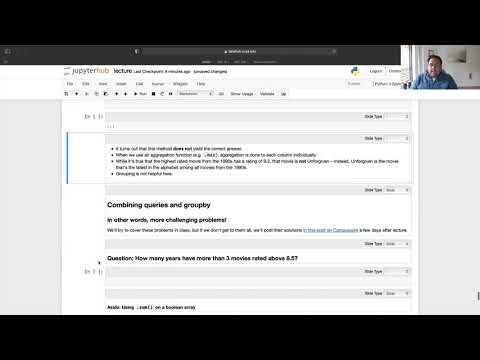

In [56]:
from IPython.display import YouTubeVideo
YouTubeVideo('xg7rnjWnZ48')

Before watching the video or looking at the solutions, **make sure to try these problems on your own** - they're great practice for working with DataFrames. 

In [57]:
imdb = pd.read_csv('data/imdb.csv').set_index('Title').sort_values(by='Rating')
imdb

,Votes,Rating,Year,Decade
Title,,,,
Akira,91652,8.0,1988,1980
Per un pugno di dollari,124671,8.0,1964,1960
Guardians of the Galaxy,527349,8.0,2014,2010
...,...,...,...,...
The Godfather: Part II,692753,9.0,1974,1970
The Shawshank Redemption,1498733,9.2,1994,1990
The Godfather,1027398,9.2,1972,1970


### Question: How many movies appear from each decade?

In [58]:
imdb.groupby('Decade').count()

,Votes,Rating,Year
Decade,,,
1920,4,4,4
1930,7,7,7
1940,14,14,14
...,...,...,...
1990,42,42,42
2000,50,50,50
2010,29,29,29


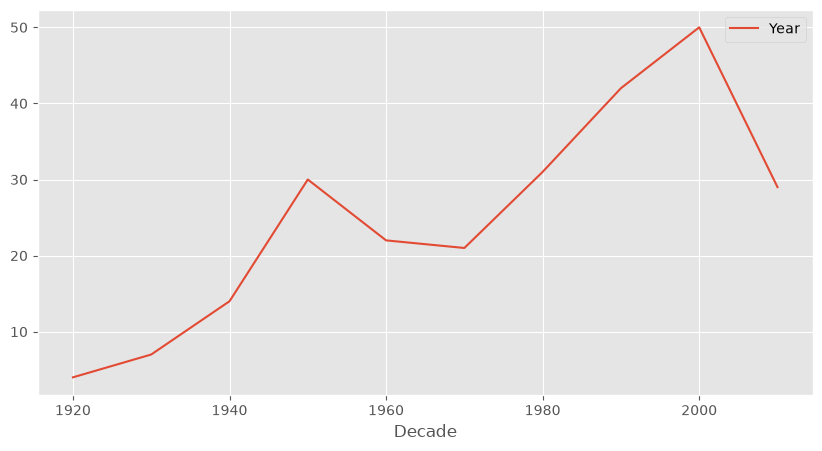

In [59]:
# We'll learn how to make plots like this in the next lecture!
imdb.groupby('Decade').count().plot(y='Year');

### Question: What was the highest rated movie of the 1990s?

Let's try to do this two different ways.

#### Without grouping

In [60]:
imdb[imdb.get('Decade') == 1990].sort_values('Rating', ascending=False).index[0]

'The Shawshank Redemption'

***Note:*** The command to extract the index of a DataFrame is `.index` - no parentheses! This is different than the way we extract columns, with `.get()`, because the index is not a column.

#### With grouping

In [61]:
imdb.reset_index().groupby('Decade').max()

,Title,Votes,Rating,Year
Decade,,,,
1920,The Kid,98794,8.3,1927
1930,The Wizard of Oz,259235,8.5,1939
1940,The Treasure of the Sierra Madre,350551,8.6,1949
...,...,...,...,...
1990,Unforgiven,1498733,9.2,1999
2000,Yip Man,1473049,8.9,2009
2010,X-Men: Days of Future Past,1271949,8.7,2015


- It turns out that this method **does not** yield the correct answer. 
- When we use an aggregation method (e.g. `.max()`), aggregation is done to each column individually. 
- While it's true that the highest rated movie from the 1990s has a rating of 9.2, that movie is **not** Unforgiven – instead, Unforgiven is the movie that's the latest in the alphabet among all movies from the 1990s.
- Taking the `max` is not helpful here.

### Question: How many years have more than 3 movies rated above 8.5?

<details>
    <summary>✅ Click <b>here</b> to see the answer.</summary>

<pre>
good_movies_per_year = imdb[imdb.get('Rating') > 8.5].groupby('Year').count()
good_movies_per_year[good_movies_per_year.get('Votes') > 3].shape[0]    
</pre>
    
As mentioned below, you can also use:
    
<pre>
(good_movies_per_year.get('Votes') > 3).sum() 
</pre>
    
</details>

#### Aside: Using `.sum()` on a boolean array

- Summing a boolean array gives a count of the number of `True` elements because Python treats `True` as 1 and `False` as 0. 
- Can you use that fact here?

### Question: Out of the years with more than 3 movies, which had the highest average rating?

<details>
    <summary>✅ Click <b>here</b> to see the answer.</summary>

<pre>
# A Series of Trues and Falses; True when there were at least 3 movies on the list from that year
more_than_3_ix = imdb.groupby('Year').count().get('Votes') > 3

# The year with the highest average rating, among the years with more than 3 movies
imdb.groupby('Year').mean()[more_than_3_ix].sort_values(by='Rating').index[-1] 
</pre>
    
</details>

### Question: Which year had the longest movie titles, on average?

**Hint:** Use `.str.len()` on the column or index that contains the names of the movies.

<details>
    <summary>✅ Click <b>here</b> to see the answer.</summary>

<pre>
(
    imdb.assign(title_length=imdb.index.str.len())
    .groupby('Year').mean()
    .sort_values(by='title_length')
    .index[-1]
)
</pre>
    
The year is 1964 – take a look at the movies from 1964 by querying!
    
</details>

### Question: What is the average rating of movies from years that had at least 3 movies in the Top 250?

<details>
    <summary>✅ Click <b>here</b> to see the answer.</summary>

<pre>
# A Series of Trues and Falses; True when there were at least 3 movies on the list from that year
more_than_3_ix = imdb.groupby('Year').count().get('Votes') > 3

# The sum of the ratings of movies from years that had at least 3 movies on the list
total_rating = imdb.groupby('Year').sum()[more_than_3_ix].get('Rating').sum()

# The total number of movies from years that had at least 3 movies on the list
count = imdb.groupby('Year').count()[more_than_3_ix].get('Rating').sum()

# The correct answer
average_rating = total_rating / count

# Close, but incorrect: 
# Doesn't account for the fact that different years have different numbers of movies on the list
close_but_wrong = imdb.groupby('Year').mean()[more_than_3_ix].get('Rating').mean()
</pre>
        
</details>

## Summary, next time

### Summary

- To write queries that involve multiple conditions:
    - Put parentheses around all conditions.
    - Separate conditions using `&` if you require all to be true, or `|` if you require at least one to be true.
- `df.groupby(column_name).agg_method()` **aggregates** all rows with the same value for `column_name` into a single row in the resulting DataFrame, using `agg_method()` to combine values.
    - Common aggregation methods include `.count()`, `.sum()`, `.mean()`, `.median()`, `.max()`, and `.min()`.
    - ***Tip:*** look for keywords "per," "for each," and "indexed by" when solving problems.

### Next time

 A picture is worth a 1000 words – it's time to visualize!